In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [3]:
!kaggle datasets download -d anthonytherrien/dog-vs-cat

Dataset URL: https://www.kaggle.com/datasets/anthonytherrien/dog-vs-cat
License(s): CC-BY-SA-4.0
100% 360M/360M [00:03<00:00, 102MB/s]



In [4]:
!kaggle datasets download -d pybear/cats-vs-dogs

Dataset URL: https://www.kaggle.com/datasets/pybear/cats-vs-dogs
License(s): CC0-1.0
100% 788M/788M [00:06<00:00, 125MB/s]



In [5]:
import zipfile
zip_ref = zipfile.ZipFile("/content/dog-vs-cat.zip")
zip_ref.extractall('/content')
zip_ref.close()

In [6]:
import zipfile
zip_ref = zipfile.ZipFile("/content/cats-vs-dogs.zip")
zip_ref.extractall('/content')
zip_ref.close()

# Search bad image

In [7]:
import os
from PIL import Image

bad_files = []

dataset_path = "/content/PetImages"  # এখানে আপনার dataset path দিন

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        path = os.path.join(root, file)
        try:
            img = Image.open(path)
            img.verify()
        except Exception as e:
            bad_files.append(path)

print("Bad files:", len(bad_files))

for f in bad_files:
    print(f)

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Bad files: 4
/content/PetImages/Cat/Thumbs.db
/content/PetImages/Cat/666.jpg
/content/PetImages/Dog/Thumbs.db
/content/PetImages/Dog/11702.jpg


# Remove bad image

In [8]:
for f in bad_files:
    os.remove(f)

# Find bad files

In [9]:
import os
from PIL import Image

dataset_path = "/content/animal"  # নিজের dataset path দিন

bad_files = []
valid_exts = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp")

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        path = os.path.join(root, file)

        # extension image না হলে bad
        if not file.lower().endswith(valid_exts):
            bad_files.append(path)
            continue

        # image open করা যায় কিনা check
        try:
            with Image.open(path) as img:
                img.verify()
        except Exception:
            bad_files.append(path)

print("Bad files found:", len(bad_files))

for f in bad_files:
    print(f)

Bad files found: 0


# bad file delete

In [10]:
for f in bad_files:
    os.remove(f)

print("Deleted bad files:", len(bad_files))

Deleted bad files: 0


In [11]:
import tensorflow as tf
import os

dataset_path = "/content/PetImages"

# bad files store করার জন্য list
bad_files = []

# scan dataset
for root, dirs, files in os.walk(dataset_path):
    for file in files:

        path = os.path.join(root, file)

        try:
            img = tf.io.read_file(path)
            img = tf.image.decode_image(img)

        except Exception as e:
            print("BAD FILE:", path)
            print(e)

            # bad file list এ store
            bad_files.append(path)

print("\nTotal bad files:", len(bad_files))


# =========================
# delete bad files
# =========================

for file_path in bad_files:

    if os.path.exists(file_path):
        os.remove(file_path)
        print("Deleted:", file_path)

print("\nAll bad files deleted successfully.")

BAD FILE: /content/PetImages/Cat/10404.jpg
{{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP, WebP required. [Op:DecodeImage] name: 
BAD FILE: /content/PetImages/Cat/4351.jpg
{{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Input size should match (header_size + row_size * abs_height) but they differ by 2 [Op:DecodeImage] name: 
BAD FILE: /content/PetImages/Dog/2494.jpg
{{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Input size should match (header_size + row_size * abs_height) but they differ by 2 [Op:DecodeImage] name: 
BAD FILE: /content/PetImages/Dog/11233.jpg
{{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Number of channels inherent in the image must be 1, 3 or 4, was 2 [Op:DecodeImage] name: 
BAD FILE: /content/PetImages/Dog/9500.jpg
{{function_node __

In [13]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, MaxPooling2D, BatchNormalization, Dropout

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
#generator

train_datagen = ImageDataGenerator(
    rescale = 1./255,
    shear_range = .2,
    zoom_range = .2,
    horizontal_flip = True
)

test_datagen = ImageDataGenerator(rescale = 1./ 255)

train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/PetImages',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256, 256)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/animals',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256, 256)
)

Found 24991 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


In [ ]:
# Normalize
def process(image, label):
  image = tf.cast(image/255., tf.float32)
  return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)


In [ ]:
train_ds

<_MapDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

# Create CNN model

In [ ]:
model = Sequential()

model.add(Conv2D(32, kernel_size=(3,3), padding='same', activation='relu', input_shape=(256, 256, 3)))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2), strides=2, padding='same'))

model.add(Conv2D(64, kernel_size=(3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2), strides=2, padding='same'))

model.add(Conv2D(128, kernel_size=(3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2), strides=2, padding='same'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    16,777,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,879,809 (64.39 MB)

 Trainable params: 16,879,361 (64.39 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(train_ds, epochs=100, validation_data=validation_ds)

Epoch 1/100
781/781 ━━━━━━━━━━━━━━━━━━━━ 80s 93ms/step - accuracy: 0.5754 - loss: 1.2561 - val_accuracy: 0.6230 - val_loss: 0.6305
Epoch 2/100
781/781 ━━━━━━━━━━━━━━━━━━━━ 72s 92ms/step - accuracy: 0.6693 - loss: 0.5936 - val_accuracy: 0.7940 - val_loss: 0.4516
Epoch 3/100
781/781 ━━━━━━━━━━━━━━━━━━━━ 69s 88ms/step - accuracy: 0.7134 - loss: 0.5457 - val_accuracy: 0.7200 - val_loss: 0.4938
Epoch 4/100
781/781 ━━━━━━━━━━━━━━━━━━━━ 72s 92ms/step - accuracy: 0.7513 - loss: 0.4872 - val_accuracy: 0.8060 - val_loss: 0.3993
Epoch 5/100
781/781 ━━━━━━━━━━━━━━━━━━━━ 69s 89ms/step - accuracy: 0.7689 - loss: 0.4671 - val_accuracy: 0.7860 - val_loss: 0.4761
Epoch 6/100
781/781 ━━━━━━━━━━━━━━━━━━━━ 69s 88ms/step - accuracy: 0.7928 - loss: 0.4126 - val_accuracy: 0.7720 - val_loss: 0.4710
Epoch 7/100
781/781 ━━━━━━━━━━━━━━━━━━━━ 71s 91ms/step - accuracy: 0.8182 - loss: 0.3565 - val_accuracy: 0.7850 - val_loss: 0.4419
Epoch 8/100
781/781 ━━━━━━━━━━━━━━━━━━━━ 69s 88ms/step - accuracy: 0.8367 - loss: 0

In [ ]:
import matplotlib.pyplot as plt

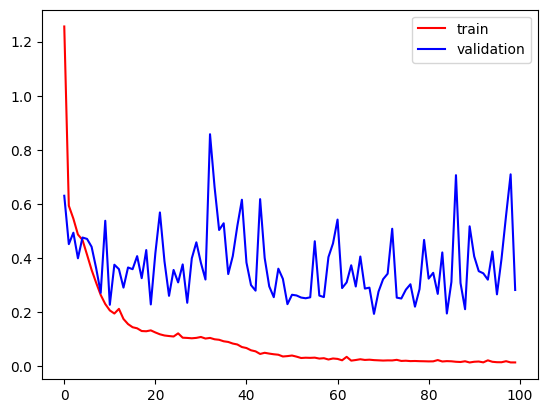

In [ ]:
plt.plot(history.history['loss'], color='red',label='train')
plt.plot(history.history['val_loss'], color='blue',label='validation')

plt.legend()
plt.show()

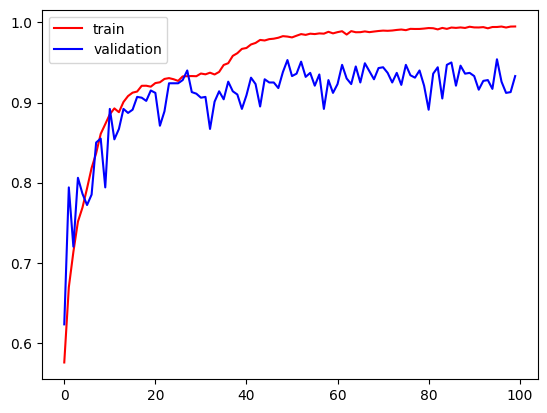

In [ ]:
plt.plot(history.history['accuracy'], color='red',label='train')
plt.plot(history.history['val_accuracy'], color='blue',label='validation')

plt.legend()
plt.show()

In [ ]:
import cv2

In [ ]:
test_img = cv2.imread('/content/Dog.jpg')

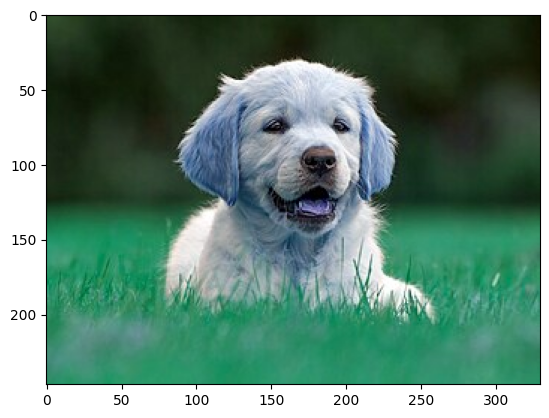

In [ ]:
plt.imshow(test_img)

In [ ]:
test_img.shape

(247, 330, 3)

In [ ]:
test_img = cv2.resize(test_img,(256,256))

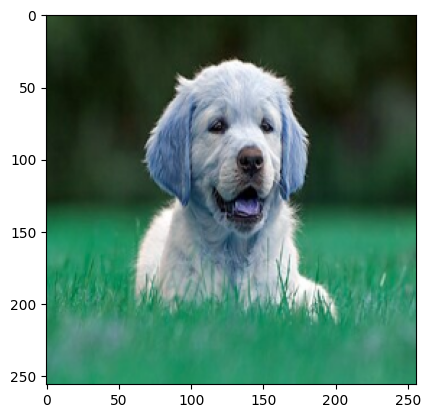

In [ ]:
plt.imshow(test_img)

In [ ]:
# for input batch
test_input = test_img.reshape((1, 256, 256, 3))

In [ ]:
pred = model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 747ms/step


In [ ]:
print("Cat") if pred == 0 else print("Dog")

Dog
